# 호르무즈 해협 크롤링 & 분석                                                                                          

### 라이브러리 불러오기

In [4]:
import pandas as pd # 데이터 조작 및 분석을 모듈
import time # 코드 실행 속도 조절을 위한 모듈
import re   # 정규표현식을 사용하여 텍스트에서 특수문자를 제거하거나 특정 패턴을 찾을 때 쓰는 모듈
import datetime # 날짜와 시간을 다루는 파이썬 기본 라이브러리

from tqdm import tqdm  # 진행상황 바 출력을 위한 라이브러리
from selenium import webdriver # 브라우저 자동화를 위한 모듈
from bs4 import BeautifulSoup as BS # HTML 내용 파싱을 위한 모듈
from selenium.webdriver.common.by import By # 다양한 방법으로 엘리먼트를 찾기 위한 모듈
from selenium.webdriver.support.ui import WebDriverWait # 브라우저가 요소를 찾을 때까지 대기(Wait)해주는 모듈
from selenium.webdriver.support import expected_conditions as EC # '어떤 상태'가 될 때까지 기다릴지 조건을 정해주는(EC) 기능 임포트

### 스크롤 다운 함수 정의

In [5]:
# 네이버 검색 결과의 무한 스크롤 특성으로 인해 처음 페이지에 접속하면 네이버는 서버 부하를 줄이기 위해 약 30개 정도의 글만 먼저 보여줌. 
# 따라서 사용자가 화면을 아래로 스크롤해야 추가로 글을 더 불러올 수 있음. -> 스코롤 다운 함수를 정의해 블로그 확보 갯수 조절 가능!

# 스크롤 다운 함수 정의
def doScrollDown(whileSeconds): 
    start = datetime.datetime.now() # 함수가 실행된 '현재 시점'의 시/분/초 가져오기
    end = start + datetime.timedelta(seconds=whileSeconds) # 입력받은 초 만큼의 시간 간격 생성
    while True:
        driver.execute_script('window.scrollTo(0, document.body.scrollHeight);') # 페이지 맨 아래로 스크롤 다운
        time.sleep(1.2) # 다음 목록이 로딩될 시간(약 1.2초)을 줌
        if datetime.datetime.now() > end: # 만약 현재 시간이 아까 계산해둔 종료 시간(end)보다 커지면 반복 break
            break 

### 브라우저(크롬) 실행 + 창 최대화

In [10]:
driver = webdriver.Chrome()
driver.maximize_window()

## '호르무즈 해협' 크롤링

### 호르무즈 해협을 둘러싼 이슈가 많은 기간(26.02.01~26.04.10)의 '호르무즈 해협' 네이버 블로그 크롤링

In [ ]:
# 26.02.01 ~ (미국, 이란 전쟁 발발일 : 26.02.28 포함) 26.04.10(현재)로 기간 설정된 '호르무즈 해협'키워드에 대한 네이버 블로그 url
naver_blog_url = 'https://search.naver.com/search.naver?ssc=tab.blog.all&query=%ED%98%B8%EB%A5%B4%EB%AC%B4%EC%A6%88%20%ED%95%B4%ED%98%91&sm=tab_opt&nso=so%3Ar%2Cp%3Afrom20260201to20260410'
driver.get(naver_blog_url)
time.sleep(2) # 검색 결과 로딩 대기

In [ ]:
# 목록 확장을 위해 스크롤
doScrollDown(20)

In [6]:
# [네이버 블로그 제목과 URL 추출 시작]

# 제목과 URL을 저장할 리스트 초기화 (나중에 카페와 구분하기 위해 blog_ 접두사 사용)
blog_title_list = []
blog_url_list = []

# 네이버가 최근 블로그 검색 결과 레이아웃을 업데이트하면서 클래스명이 무작위 문자열이 섞인 형태로 바뀐것을 F12키를 활용해 인지했습니다.
# 이런 클래스명은 네이버가 코드를 업데이트할 때마다 수시로 바뀌기 때문에, '클래스 이름' 대신 해당 클래스의 '구조'나 '속성'을 이용해 크롤링하는 것이 좋다고 느꼈습니다.
# <a> 태그 중에서 'data-heatmap-target' 속성값이 '.nblg'인 것만 골라내기
found_blog_elements = driver.find_elements(By.CSS_SELECTOR, 'a[data-heatmap-target=".nblg"]')

# 찾아낸 여러 개의 요소(found_blog_elements)를 하나씩 꺼내어 반복문 돌리기
for element in found_blog_elements:
    title_text = element.text.strip()
    url_link = element.get_attribute('href')
    
    if title_text and url_link: # 제목과 주소가 모두 정상적으로 존재할 때만 리스트에 추가 (빈 값 방지)
        blog_title_list.append(title_text) # 제목 리스트에 추가
        blog_url_list.append(url_link)     # 주소 리스트에 추가

# 중복 제거 (데이터 정제)
# 대량 수집 시 중복된 글을 피하기 위해 판다스 데이터프레임을 활용합니다.
df_blog_temp = pd.DataFrame({'title': blog_title_list, 'url': blog_url_list})

# subset=['url'] = 주소(url) 컬럼을 기준으로 중복된 블로그인지 검사해"라는 뜻
# keep='first' = 만약 똑같은 주소가 여러 개 발견되면, 가장 처음에 나온 것 하나만 남기고 나머지는 버려"라는 뜻
df_blog_temp = df_blog_temp.drop_duplicates(subset=['url'], keep='first')

# 중복 제거된 데이터를 다시 우리가 사용할 리스트로 변환
blog_title_list = df_blog_temp['title'].tolist()
blog_url_list = df_blog_temp['url'].tolist()

print(f"✅ 총 {len(blog_url_list)}개의 중복 없는 네이버 블로그 주소를 확보했습니다.")

✅ 총 540개의 중복 없는 네이버 블로그 주소를 확보했습니다.


In [13]:
from tqdm import tqdm # 진행상황 파악을 위한 tqdm 라이브러리 추가

# --- [네이버 블로그 상세 데이터 수집: 본문, 좋아요, 댓글 수, 댓글 내용] ---
# 1. 수집한 데이터를 담을 리스트 초기화
blog_new_doc = []      # 각 블로그의 전체 본문 텍스트
blog_like_cnt = []     # 공감(좋아요) 숫자
blog_comment_cnt = []  # 댓글 개수 숫자
blog_comment_list = [] # 댓글 텍스트 내용 (분석용)

# 2. 앞서 수집한 blog_url_list(블로그 주소 목록)를 순회하며 개별 페이지 접속
# 기존의 range(len(...))을 tqdm으로 감싸 시각적인 진행 바를 표시합니다.
for i in tqdm(range(len(blog_url_list)), desc="네이버 블로그 수집 진행 중"): 
    # [Tip] 새 탭을 열어 접속하는 방식은 메인 목록 탭을 유지할 수 있어 안정적입니다.
    driver.execute_script(f"window.open('{blog_url_list[i]}')")
    driver.switch_to.window(driver.window_handles[1]) # 새로 열린 탭(인덱스 1번)으로 제어권 이동
    
    # 페이지 로딩을 기다리기 위한 명시적 대기(Explicit Wait) 설정
    wait = WebDriverWait(driver, 3) 
    
    try:
        # [핵심] 네이버 블로그는 본문이 'mainFrame'이라는 iframe 안에 들어있습니다.
        # 이 프레임으로 전환하지 않으면 본문 안의 요소를 절대 찾을 수 없습니다.
        wait.until(EC.frame_to_be_available_and_switch_to_it((By.ID, 'mainFrame')))
        
        # 현재 프레임의 HTML 소스를 가져와 BeautifulSoup으로 파싱
        html = driver.page_source
        soup = BS(html, 'html.parser')
        
        # --- (1) 본문 텍스트 추출 ---
        try:
            # 네이버 블로그의 본문 영역 클래스는 보통 '.se-main-container'입니다. (구 버전은 #postViewArea)
            content = soup.select_one('.se-main-container, #postViewArea').get_text(strip=True)
        except:
            # 본문을 찾지 못하는 예외 상황(글 삭제, 비공개 등) 처리
            content = "본문 없음"
        blog_new_doc.append(content)

        # --- (2) 좋아요(공감) 수 추출 ---
        try:
            # [Tip] 공감 버튼은 화면 하단에 있어, 스크롤을 끝까지 내려야 데이터가 활성화되는 경우가 많습니다.
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);") 
            
            # 좋아요 숫자가 담긴 요소를 기다림
            like_el = WebDriverWait(driver, 2).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "span.u_likeit_text._count.num"))
            )
            # 'textContent' 속성은 숨겨져 있거나 화면에 보이지 않는 텍스트도 강제로 가져옵니다.
            like_val = like_el.get_attribute('textContent').strip()
            
            # 숫자가 아니거나 비어있으면 0으로 초기화 (데이터 정제)
            if not like_val or not like_val.isdigit(): 
                like_val = "0"
        except:
            like_val = "0"
        blog_like_cnt.append(like_val)

        # --- (3) 댓글 개수 추출 ---
        try:
            # 댓글 버튼에 표시된 숫자를 추출
            comment_num = driver.find_element(By.ID, "commentCount").get_attribute('textContent').strip()
            if not comment_num: 
                comment_num = "0"
        except:
            comment_num = "0"
        blog_comment_cnt.append(comment_num)

        # --- (4) 댓글 실제 내용 추출 ---
        try:
            # 댓글 버튼을 찾아 클릭해야 댓글 창이 로드됩니다.
            # 일반 click()보다 자바스크립트를 이용한 클릭이 가려진 요소 클릭에 더 강합니다.
            comment_btn = driver.find_element(By.ID, "commentCount") 
            driver.execute_script("arguments[0].click();", comment_btn) 
            time.sleep(1) # 댓글창이 서버로부터 데이터를 받아오는 시간 대기
            
            # 댓글 텍스트가 담긴 모든 요소(u_cbox_contents)를 수집
            comments = driver.find_elements(By.CLASS_NAME, "u_cbox_contents") 
            # 여러 개의 댓글을 줄바꿈(\n)으로 구분하여 하나의 문자열로 합침
            blog_comment_final = "\n".join([c.text for c in comments]) if comments else "댓글 없음" 
        except:
            # 댓글 기능이 비활성화되었거나 접근 불가능한 경우
            blog_comment_final = "댓글 막힘" 
        blog_comment_list.append(blog_comment_final)

    except Exception as e:
        # 특정 게시글 수집 중 예상치 못한 오류 발생 시 처리
        # tqdm 환경에서는 print 대신 tqdm.write를 사용하는 것이 진행 바 깨짐을 방지합니다.
        tqdm.write(f"⚠️ {i+1}번 글 수집 실패: {e}")
        blog_new_doc.append("에러 발생")
        blog_like_cnt.append("0")
        blog_comment_cnt.append("0")
        blog_comment_list.append("에러 발생")

    # [중요] 사용이 끝난 상세 탭을 닫고, 다시 목록 페이지가 있는 0번 탭으로 제어권 복구
    driver.close()
    driver.switch_to.window(driver.window_handles[0])

# 모든 수집이 끝나면 브라우저 종료 및 최종 메시지
driver.quit()
print("✅ 수집 완료!")

네이버 블로그 수집 진행 중: 100%|██████████| 540/540 [25:35<00:00,  2.84s/it]


✅ 수집 완료!


In [14]:
# 1. 수집된 리스트들을 하나의 데이터프레임(DataFrame)으로 결합
df_blog = pd.DataFrame({
    'title': blog_title_list,        # 글 제목
    'url': blog_url_list,            # 글 주소
    'doc': blog_new_doc,             # 본문 내용
    'like': blog_like_cnt,           # 좋아요(공감) 수
    'comment_cnt': blog_comment_cnt,  # 댓글 수
    'comment_list': blog_comment_list, # 댓글 내용
    'ch': 'naver',                   # 채널 구분 1 (네이버)
    'ch2': 'blog'                    # 채널 구분 2 (블로그)
})

# 2. 데이터 유효성 확인
# 수집 과정에서 본문이 비었거나 에러가 난 항목이 있는지 상위 5개를 출력해 확인합니다.
print("📊 [검토] 네이버 블로그 데이터 생성 완료 (상위 5행):")
print(df_blog.head())

# 3. 파일 저장 (파일명: 26.02.01~26.04.10_naver_blog_data.csv)
file_name = '26.02.01~26.04.10_naver_blog_data.csv'

# encoding='utf-8-sig'는 엑셀에서 한글이 깨지지 않게 방지해주는 설정입니다.
df_blog.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"✅ 파일 저장 완료: {file_name}")
print(f"총 {len(df_blog)}개의 블로그 데이터가 안전하게 기록되었습니다.")

📊 [검토] 네이버 블로그 데이터 생성 완료 (상위 5행):
                                 title  \
0  미국 이란 전쟁 30일 경과, 호르무즈 해협 지도로 본 현 상황   
1    호르무즈 해협 통행료가 얼마길래? 미국 이란 공동 징수 추진   
2   뉴욕 증시 트럼프 발언 속 혼조세, 호르무즈 해협 통행료 이슈   
3   트럼프 “호르무즈 해협 이름 바꾼다!?”… 이거 진짜 가능한가   
4       호르무즈 해협 봉쇄 이유와 영향, 유가 상승·증시 전망   

                                               url  \
0      https://blog.naver.com/3f-hoon/224233386857   
1   https://blog.naver.com/totoro3123/224246051445   
2    https://blog.naver.com/archimall/224239139022   
3  https://blog.naver.com/kimsong8106/224233276505   
4   https://blog.naver.com/dldnsgud91/224201238593   

                                                 doc like comment_cnt  \
0  ​미국과 이란의 전쟁이 지난 2월 28일에 발발해 한 달이 지났습니다.​빠르게 끝날...   16           4   
1  안녕하세요.​네이버 경제인플루언서 주식너부리입니다.​4월 8일(현지시각) 도널드 트...   41           4   
2  최근 중동 지역의 긴장감이 고조되면서 투자자들의 심리가 얼음판 위를 걷는 듯한 모습...   89           4   
3  ​​최근 외신 보도를 보면 도널드 트럼프 대통령이 중동의 핵심 요충지인 호르무즈 해...   25           2   
4  ​최근 뉴스에서 “호르무즈 해협 봉쇄

### 호르무즈 해협을 둘러싼 이슈가 많은 기간(26.02.01~26.04.10) '호르무즈 해협' 네이버 카페 크롤링

In [15]:
# 브라우저 실행 & 최대화
driver = webdriver.Chrome()
driver.maximize_window()

In [16]:
# 26.02.01 ~ (미국, 이란 전쟁 발발일 : 26.02.28 포함) 26.04.10(현재)로 기간 설정된 '호르무즈 해협'키워드에 대한 네이버 카페 url
# 네이버 카페 검색 옵션에서 '일반글' 선택으로 불필요한 데이터인 '거래글'수집 사전 차단.
naver_cafe_url = "https://search.naver.com/search.naver?cafe_where=articleg&nso=so%3Ar%2Cp%3Afrom20260201to20260410&nso_open=1&prdtype=0&query=%ED%98%B8%EB%A5%B4%EB%AC%B4%EC%A6%88+%ED%95%B4%ED%98%91&sm=mtb_opt&ssc=tab.cafe.all&st=rel&stnm=rel&opt_tab=0&nso=so%3Ar%2Cp%3Afrom20260201to20260410&date_from=20260201&date_to=20260410"
driver.get(naver_cafe_url)
time.sleep(2) # 페이지 로딩 대기

In [19]:
# 목록 확장을 위해 스크롤
doScrollDown(20)

In [20]:
# --- [네이버 카페 제목과 URL 추출 시작] ---

# 제목과 URL을 저장할 리스트 초기화 (나중에 블로그와 구분하기 위해 cafe_ 접두사 사용)
cafe_title_list = []
cafe_url_list = []

# BeautifulSoup으로 현재 페이지의 HTML 소스를 가져옵니다. (속도 최적화를 위해 BS 활용)
html = driver.page_source
soup = BS(html, 'html.parser')

# 네이버 카페 검색 결과의 게시글 요소들을 선택합니다.
# 카페 역시 클래스명이 바뀔 수 있으므로, 공통적인 구조인 '.view_wrap' 내부의 '.title_link'를 활용합니다.
found_cafe_elements = soup.select('.view_wrap .title_link')

# 찾아낸 여러 개의 요소들을 하나씩 꺼내어 반복문을 돌립니다.
for element in found_cafe_elements:
    title_text = element.get_text(strip=True)
    url_link = element['href']
    
    if title_text and url_link: # 제목과 주소가 모두 정상적으로 존재할 때만 리스트에 추가 (빈 값 방지)
        cafe_title_list.append(title_text) # 제목 리스트에 추가
        cafe_url_list.append(url_link)     # 주소 리스트에 추가

# [중복 제거 - 데이터 정제]
# 대량 수집 시 중복된 글을 피하기 위해 판다스 데이터프레임을 활용합니다.
df_cafe_temp = pd.DataFrame({'title': cafe_title_list, 'url': cafe_url_list})

# 주소(url) 컬럼을 기준으로 중복된 카페 글인지 검사하여 첫 번째 것만 남깁니다.
df_cafe_temp = df_cafe_temp.drop_duplicates(subset=['url'], keep='first')

# 중복 제거된 데이터를 다시 우리가 상세 수집에서 사용할 리스트로 변환
cafe_title_list = df_cafe_temp['title'].tolist()
cafe_url_list = df_cafe_temp['url'].tolist()

print(f"✅ 총 {len(cafe_url_list)}개의 중복 없는 네이버 카페 주소를 확보했습니다.")

✅ 총 540개의 중복 없는 네이버 카페 주소를 확보했습니다.


In [21]:
# --- [네이버 카페 상세 데이터 수집: 본문, 좋아요, 댓글 수, 댓글 내용] ---
# 1. 데이터를 저장할 리스트들 초기화 (네이버 카페용 접두사 cafe_ 사용)
cafe_new_doc = []      # 1. 본문
cafe_like_cnt = []     # 2. 좋아요(공감) 수
cafe_comment_cnt = []  # 3. 댓글 수
cafe_comment_list = [] # 4. 댓글 내용

# 2. cafe_url_list에 저장된 주소 개수만큼 반복문을 실행
# tqdm을 사용하여 카페 데이터 수집 진행률을 시각화합니다.
for i in tqdm(range(len(cafe_url_list)), desc="네이버 카페 상세 수집 중", unit="post"): 
    driver.execute_script(f"window.open('{cafe_url_list[i]}')")
    driver.switch_to.window(driver.window_handles[1]) # 새로 열린 탭으로 제어권 전환
    
    wait = WebDriverWait(driver, 3)
    
    try:
        # [핵심] 네이버 카페는 본문이 'cafe_main'이라는 iframe 안에 들어있습니다.
        # 블로그(mainFrame)와 아이디가 다르므로 주의가 필요합니다.
        wait.until(EC.frame_to_be_available_and_switch_to_it((By.ID, 'cafe_main')))
        time.sleep(0.5) # 카페 메인 프레임 로딩 후 안정적인 파싱을 위해 살짝 대기
        
        html = driver.page_source
        soup = BS(html, 'html.parser')
        
        # --- (1) 본문 텍스트 추출 ---
        try:
            # 카페 에디터 버전에 따라 클래스명이 다를 수 있어 여러 선택자를 지정합니다.
            content = soup.select_one('.se-main-container, .ContentRenderer, .article_viewer').get_text(strip=True)
        except: 
            content = "본문 없음"
        cafe_new_doc.append(content)

        # --- (2) 좋아요(공감) 수 추출 ---
        try:
            # 페이지 하단으로 스크롤하여 좋아요 요소를 활성화
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            
            # 카페의 좋아요 숫자는 em.u_cnt._count 등에 위치합니다.
            like_el = WebDriverWait(driver, 2).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "em.u_cnt._count"))
            )
            like_val = like_el.get_attribute('textContent').strip()
            
            # 숫자가 비어있거나 숫자가 아니면 '0'으로 처리
            if not like_val or not like_val.replace(',', '').isdigit(): 
                like_val = "0"
        except: 
            like_val = "0"
        cafe_like_cnt.append(like_val)

        # --- (3) 댓글 수 추출 ---
        try:
            # 댓글창 영역 근처의 숫자 요소를 찾습니다.
            comment_num_el = driver.find_element(By.CSS_SELECTOR, "strong.num, .comment_count")
            comment_num = comment_num_el.get_attribute('textContent').strip()
            
            # 숫자 외의 문자(쉼표 등) 제거
            comment_num = re.sub(r'[^0-9]', '', comment_num)
            if not comment_num: 
                comment_num = "0"
        except: 
            comment_num = "0"
        cafe_comment_cnt.append(comment_num)

        # --- (4) 댓글 실제 내용 추출 ---
        try:
            # 댓글 버튼(혹은 댓글 영역)을 찾아 클릭하여 내용을 펼칩니다.
            comment_btn = driver.find_element(By.CSS_SELECTOR, "a.button_comment, .btn_comment")
            driver.execute_script("arguments[0].click();", comment_btn) 
            time.sleep(1) # 비동기 로딩 대기
            
            # 카페 댓글 내용 요소(comment_text_view)를 모두 수집
            comments = driver.find_elements(By.CLASS_NAME, "comment_text_view")
            cafe_comment_final = "\n".join([c.text for c in comments]) if comments else "댓글 없음"
        except:
            cafe_comment_final = "댓글 막힘" 
        cafe_comment_list.append(cafe_comment_final)

    except Exception as e:
        # 진행 바 깨짐 방지를 위해 tqdm.write 사용
        tqdm.write(f"⚠️ {i+1}번 카페 글 수집 중 오류 발생")
        cafe_new_doc.append("에러 발생")
        cafe_like_cnt.append("0")
        cafe_comment_cnt.append("0")
        cafe_comment_list.append("에러 발생")

    # 작업 완료 후 탭을 닫고 다시 목록 탭(0번)으로 복귀
    driver.close()
    driver.switch_to.window(driver.window_handles[0])

# 모든 작업 완료 후 드라이버 종료
driver.quit()
print("✅ 수집완료!")

네이버 카페 상세 수집 중: 100%|██████████| 540/540 [22:20<00:00,  2.48s/post]


✅ 수집완료!


In [22]:
# 1. 수집된 카페 리스트들을 하나의 데이터프레임(DataFrame)으로 결합
# 블로그 데이터프레임과 컬럼 순서 및 이름을 동일하게 맞추어 나중에 merge(concat)하기 편하게 만듭니다.
df_cafe = pd.DataFrame({
    'title': cafe_title_list,         # 글 제목
    'url': cafe_url_list,             # 글 주소
    'doc': cafe_new_doc,              # 본문 내용
    'like': cafe_like_cnt,            # 좋아요(공감) 수
    'comment_cnt': cafe_comment_cnt,   # 댓글 수
    'comment_list': cafe_comment_list, # 댓글 내용
    'ch': 'naver',                    # 채널 구분 1 (네이버)
    'ch2': 'cafe'                     # 채널 구분 2 (카페)
})

# 2. 데이터 확인 (제대로 수집되었는지 상위 5개 미리보기)
print("📊 [검토] 네이버 카페 데이터 생성 완료 (상위 5행):")
print(df_cafe.head())

# 3. 파일 저장 (파일명 규칙: 26.02.01~26.04.10_naver_cafe_data.csv)
# 블로그 파일과 동일한 기간을 명시하여 세트로 관리합니다.
file_name_cafe = '26.02.01~26.04.10_naver_cafe_data.csv'

# encoding='utf-8-sig'를 사용하여 한글 깨짐을 방지합니다.
df_cafe.to_csv(file_name_cafe, index=False, encoding='utf-8-sig')

print("-" * 30)
print(f"✅ 파일 저장 완료: {file_name_cafe}")
print(f"총 {len(df_cafe)}개의 카페 게시글 데이터가 저장되었습니다.")

📊 [검토] 네이버 카페 데이터 생성 완료 (상위 5행):
                                   title  \
0        트럼프 미국 이란 전쟁 초토화 선언과호르무즈 해협의 위기   
1     대한민국 '최악의 시나리오'가 왔다. (호르무즈 해협의 위기)   
2  호르무즈 해협개방 됐다는 말 사실일까? 휴전 이후 통항 조건 총정리   
3              [시사 상식] 세계 경제의 목줄,호르무즈 해협   
4          호르무즈 해협내 '대체항로'를 전격 발표 내용정리..   

                                                 url  \
0  https://cafe.naver.com/ssadanicar/180205?art=Z...   
1  https://cafe.naver.com/jaegebal/6226887?art=ZX...   
2  https://cafe.naver.com/cantsb/3251642?art=ZXh0...   
3  https://cafe.naver.com/readbook/2695518?art=ZX...   
4  https://cafe.naver.com/geobuk2/2103829?art=ZXh...   

                                                 doc like comment_cnt  \
0  트럼프 미국 대통령 이란 관련 소식이 전해지면서 전 세계가 긴장하고 있는데 개전 3...    0           4   
1  게시판 안내를 확인해 주세요!*실거래가 게시글에 관한 의견을 묻습니다.https:/...   58          11   
2  게시판 안내를 확인해 주세요!🎁참여자 전원 100% 선물 증정! 👉참여 소요 시간 ...    4          13   
3  북극성 여러분, 안녕하세요😊오늘 오후 7시, 내일부터 적용될 3차 석유 최고 가격이...    4           0   


### 호르무즈 해협을 둘러싼 이슈가 많은 기간(26.02.01~26.04.10) '호르무즈 해협' 데이터 전처리 & 통합

In [6]:
# 특수문자 제거 및 공백 정규화 함수 정의
def clean_text(text):
    # 결측치(NaN) 또는 데이터가 비어있는 경우 처리
    if pd.isna(text) or str(text).strip() == "": 
        return ""
    
    # 한글, 영문, 숫자, 공백만 남기고 모든 특수문자 제거
    cleaned = re.sub("[^0-9a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣 ]", '', str(text))
    
    # 여러 개의 공백을 하나로 줄이고 양끝 공백 제거
    cleaned = ' '.join(cleaned.split())
    return cleaned

try:
    # 1. 데이터 불러오기
    df_blog = pd.read_csv('26.02.01~26.04.10_naver_blog_data.csv')
    df_cafe = pd.read_csv('26.02.01~26.04.10_naver_cafe_data.csv')
    
    # 2. 데이터 통합 (Merge)
    # 두 데이터를 세로로 이어 붙여 하나의 데이터프레임으로 만듭니다.
    df_total = pd.concat([df_blog, df_cafe], ignore_index=True)
    initial_count = len(df_total)
    print(f"✅ 1. 데이터 통합 완료 (총 {initial_count}건)")

    # 3. [정제] 제목, 본문, 댓글 컬럼에 특수문자 제거 적용
    cols_to_clean = ['title', 'doc', 'comment_list']
    
    for col in cols_to_clean:
        if col in df_total.columns:
            # 미리 정의한 clean_text 함수 일괄 적용
            df_total[col] = df_total[col].apply(clean_text)
            
            # 특수문자 제거 후 내용이 사라진 경우 '내용없음'으로 채움 (추후 필터링 위함)
            df_total[col] = df_total[col].replace('', '내용없음')
    
    print("✅ 2. 특수문자 제거 및 내용 정제 완료")

    # 4. [필터링] 유의미한 분석을 위한 노이즈 제거
    # 본문(doc)의 길이가 2글자 미만인 데이터 삭제
    df_total = df_total[df_total['doc'].str.len() >= 2]
    
    # '본문 없음', '내용없음' 등으로 기록된 행 추가 필터링
    df_total = df_total[~df_total['doc'].isin(['본문 없음', '내용없음'])]
    print("✅ 3. 노이즈 및 결측 데이터 필터링 완료")

    # 5. [중복 제거] 본문이 완전히 같은 글은 하나만 남기고 삭제
    # (카페 스크랩 글이나 중복 수집된 게시글 정리)
    df_total = df_total.drop_duplicates(subset=['doc'], keep='first')
    print("✅ 4. 본문 기준 중복 데이터 제거 완료")

    # 6. 인덱스 재설정 및 결과 출력
    # 행이 삭제되어 비어있는 인덱스 번호를 0부터 다시 순서대로 매깁니다.
    df_total = df_total.reset_index(drop=True)
    final_count = len(df_total)

    print(f"📊 [중간 점검 결과]")
    print(f"초기 데이터: {initial_count}건")
    print(f"정제 후 데이터: {final_count}건")
    print(f"제거된 노이즈/중복: {initial_count - final_count}건")
    print("'df_total' 변수에 정제된 데이터가 담겼습니다.")

except Exception as e:
    print(f"❌ 오류 발생: {e}")

✅ 1. 데이터 통합 완료 (총 1080건)
✅ 2. 특수문자 제거 및 내용 정제 완료
✅ 3. 노이즈 및 결측 데이터 필터링 완료
✅ 4. 본문 기준 중복 데이터 제거 완료
📊 [중간 점검 결과]
초기 데이터: 1080건
정제 후 데이터: 1021건
제거된 노이즈/중복: 59건
'df_total' 변수에 정제된 데이터가 담겼습니다.


### 호르무즈 해협을 둘러싼 이슈가 많은 기간(26.02.01~26.04.10) '호르무즈 해협' 데이터 결측값 정리

In [7]:
# 1. 원본 데이터 개수 확인 (앞서 통합한 df_total을 복사해서 사용)
df = df_total.copy()
original_cnt = len(df)

# 2. 결측값 및 단문 정리 (본문 & 댓글 통합 필터링)
# .str.strip()으로 공백을 제거한 후, 순수 글자 수가 2자 이상인 행만 남깁니다.

# 본문(doc) 필터링: 2자 미만 제거
df = df[df['doc'].str.strip().str.len() >= 2]

# 댓글(comment_list) 필터링: 2자 미만 제거 (인사말이나 짧은 이모티콘 등 노이즈 제거)
df = df[df['comment_list'].str.strip().str.len() >= 2]

# 3. '내용없음'으로 표시된 데이터 최종 삭제
# 이전 정제 단계에서 빈 값 대신 채워넣었던 '내용없음' 문자열을 솎아냅니다.
df = df[df['doc'] != '내용없음']
df = df[df['comment_list'] != '내용없음']

# 4. 인덱스 재설정
# 행이 삭제되면 인덱스가 (0, 2, 5...) 처럼 비게 되는데, 
# 이를 0부터 다시 순서대로 매겨야 이후 형태소 분석 루프가 끊기지 않습니다.
df = df.reset_index(drop=True)

# 5. 결과 보고
final_cnt = len(df)
print("-" * 30)
print(f"🧹 결측치 및 단문 정리 완료!")
print(f"📊 정리 전: {original_cnt}개 -> 정리 후: {final_cnt}개")
print(f"🗑️ 제거된 데이터: {original_cnt - final_cnt}개")
print("-" * 30)

# 6. 데이터 최종 확인 (상위 5행 출력)
# 주피터 노트북 환경이라면 display(df.head())를, 일반 환경이라면 print(df.head())를 사용하세요.
try:
    display(df.head())
except NameError:
    print(df.head())

------------------------------
🧹 결측치 및 단문 정리 완료!
📊 정리 전: 1021개 -> 정리 후: 1012개
🗑️ 제거된 데이터: 9개
------------------------------


,title,url,doc,like,comment_cnt,comment_list,ch,ch2
0,미국 이란 전쟁 30일 경과 호르무즈 해협 지도로 본 현 상황,https://blog.naver.com/3f-hoon/224233386857,미국과 이란의 전쟁이 지난 2월 28일에 발발해 한 달이 지났습니다빠르게 끝날 것 ...,16,4,좋은 하루 되세요 늦었지만 답방 왔어요정성글 잘 보고 갑니다,naver,blog
1,호르무즈 해협 통행료가 얼마길래 미국 이란 공동 징수 추진,https://blog.naver.com/totoro3123/224246051445,안녕하세요네이버 경제인플루언서 주식너부리입니다4월 8일현지시각 도널드 트럼프 미국 ...,41,4,호르무즈 해협 통행료가 얼마길래 미국 이란 공동 징수 추진 관련 글 잘 봤어요 좋은...,naver,blog
2,뉴욕 증시 트럼프 발언 속 혼조세 호르무즈 해협 통행료 이슈,https://blog.naver.com/archimall/224239139022,최근 중동 지역의 긴장감이 고조되면서 투자자들의 심리가 얼음판 위를 걷는 듯한 모습...,89,4,정보가 알차서 한 번에 해결됐네요디스커버님 중동 긴장 속 시장 변동성이 컸네요 다행...,naver,blog
3,트럼프 호르무즈 해협 이름 바꾼다 이거 진짜 가능한가,https://blog.naver.com/kimsong8106/224233276505,최근 외신 보도를 보면 도널드 트럼프 대통령이 중동의 핵심 요충지인 호르무즈 해협 ...,25,2,이름 바꾸는 건 쉬운 일이 아니야 역사와 지리의 깊이를 생각해보면 단순한 변화보다는...,naver,blog
4,호르무즈 해협 봉쇄 이유와 영향 유가 상승증시 전망,https://blog.naver.com/dldnsgud91/224201238593,최근 뉴스에서 호르무즈 해협 봉쇄 가능성이라는 표현이 자주 등장하고 있습니다 이 표...,90,3,좋은 정보 감사합니다매우 유익한 정보 입니다손 도장 꾹 찍고 갑니다제 블로그도 방문...,naver,blog


### 호르무즈 해협을 둘러싼 이슈가 많은 기간(26.02.01~26.04.10) '호르무즈 해협' 데이터 토큰화 및 형태소 분석

#### soynlp 사용 : soynlp는 데이터의 통계적 패턴을 학습해서 단어를 찾기 때문에 kiwi, Okt보다 유리할 수 있고, 무엇보다 커널 충돌을 최소화할 수 있어서 채택.

##### soynlp 학습 및 추출기 준비

In [8]:
from soynlp.noun import LRNounExtractor_v2
from tqdm import tqdm

# 1. 명사 추출기 초기화
noun_extractor = LRNounExtractor_v2(verbose=True)

# 2. 전체 본문 데이터를 학습시킵니다. (데이터의 통계적 특징 파악)
# 리스트 형태로 본문을 전달합니다.
print("🧠 데이터 학습 중...")
noun_extractor.train(df_total['doc'].tolist())

# 3. 학습된 결과에서 명사 사전 추출
nouns = noun_extractor.extract()
print(f"✅ 학습 완료! 총 {len(nouns)}개의 명사 후보를 찾았습니다.")

[Noun Extractor] use default predictors
[Noun Extractor] num features: pos=3929, neg=2321, common=107
🧠 데이터 학습 중...
[Noun Extractor] counting eojeols
[EojeolCounter] n eojeol = 85390 from 1021 sents. mem=0.193 Gb                    
[Noun Extractor] complete eojeol counter -> lr graph
[Noun Extractor] has been trained. #eojeols=314916, mem=0.355 Gb
[Noun Extractor] batch prediction was completed for 26735 words
[Noun Extractor] checked compounds. discovered 19019 compounds
[Noun Extractor] postprocessing detaching_features : 25127 -> 21284
[Noun Extractor] postprocessing ignore_features : 21284 -> 21151
[Noun Extractor] postprocessing ignore_NJ : 21151 -> 20868
[Noun Extractor] 20868 nouns (19019 compounds) with min frequency=1
[Noun Extractor] flushing was done. mem=0.391 Gb                    
[Noun Extractor] 75.30 % eojeols are covered
✅ 학습 완료! 총 20868개의 명사 후보를 찾았습니다.


##### 본문 및 댓글에서 명사 추출 (토큰화)

In [12]:
# 결과를 담을 리스트 (제목용 추가)
title_noun_list = []
doc_noun_list = []
comment_noun_list = []

# 학습된 명사들의 집합
noun_dict = set(nouns.keys())

print("📝 제목, 본문, 댓글에서 각각 명사를 추출합니다...")

for i in tqdm(range(len(df_total)), desc="soynlp 토큰화 중"):
    # (A) 제목 처리 (추가)
    t_text = str(df_total['title'][i])
    t_nouns = [word for word in t_text.split() if word in noun_dict]
    title_noun_list.append(' '.join(t_nouns))
    
    # (B) 본문 처리
    d_text = str(df_total['doc'][i])
    d_nouns = [word for word in d_text.split() if word in noun_dict]
    doc_noun_list.append(' '.join(d_nouns))
    
    # (C) 댓글 처리
    c_text = str(df_total['comment_list'][i])
    c_nouns = [word for word in c_text.split() if word in noun_dict]
    comment_noun_list.append(' '.join(c_nouns))

# 데이터프레임에 새로운 컬럼으로 저장
df_total['title_noun'] = title_noun_list
df_total['doc_noun'] = doc_noun_list
df_total['comment_noun'] = comment_noun_list

print("\n✅ 모든 텍스트의 명사 추출이 완료되었습니다!")
print("-" * 30)
# 결과 확인
display(df_total[['title_noun', 'doc_noun', 'comment_noun']].head())

📝 제목, 본문, 댓글에서 각각 명사를 추출합니다...


soynlp 토큰화 중: 100%|██████████| 1021/1021 [00:00<00:00, 6986.97it/s]


✅ 모든 텍스트의 명사 추출이 완료되었습니다!
------------------------------


,title_noun,doc_noun,comment_noun
0,미국 전쟁 30일 호르무즈 해협 상황,2월 달이 것 이번 계속 외교적 더 주요 종식 26일이란은 위한 제시했습니다미국이 ...,하루 잘
1,호르무즈 해협 미국 공동 징수 추진,안녕하세요네이버 경제인플루언서 트럼프 미국 대통령이 호르무즈해협 수 언급한 점 해협...,호르무즈 해협 미국 공동 징수 추진 관련 글 잘 하루 호르무즈 해협 정말 정보 하루
2,증시 트럼프 발언 속 혼조세 호르무즈 해협 통행료,최근 중동 호르무즈 아시아 제외하고 호르무즈 해협 통행료 협의 공동체 이번주 마무리...,중동 긴장 속 시장 다행히 해결 모색 금요일 정보 하루
3,트럼프 호르무즈 해협 이름 이거 진짜,최근 외신 보면 트럼프 대통령이 핵심 호르무즈 해협 검토 트럼프 이거 진짜 해협 이...,이름 건 쉬운 더 것 정보 하루
4,호르무즈 해협 봉쇄 영향 유가 상승증시 전망,최근 호르무즈 해협 봉쇄 등장하고 수도 있지만 사실 지역 세계 영향을 수 핵심 유가...,정보 정보 하루 그렇게 중요한 정말 세계 유조선 피격 수 때 더 주의 듭니다 전략 ...


### 호르무즈 해협을 둘러싼 이슈가 많은 기간(26.02.01~26.04.10) '호르무즈 해협' 데이터 불용어 제거

#### stopwords-ko.txt 활용

In [14]:
import os

# 1. 불용어 텍스트 파일 경로 (r을 붙여서 경로 인식 오류 방지)
file_path = r'C:\Users\황태하\Crawling_practice\stopwords-ko\stopwords-ko.txt'

try:
    # 2. 파일 읽기 (with 문 사용으로 자원 관리 최적화)
    if os.path.exists(file_path):
        with open(file_path, "r", encoding="UTF-8") as f:
            # line.strip()으로 \n(줄바꿈) 제거 + 빈 줄 제외하고 리스트 생성
            st = [line.strip() for line in f.readlines() if line.strip()]
        
        print(f"✅ 외부 불용어 사전 로드 성공! (총 {len(st)}개 단어)")
        print(f"🔍 로드된 불용어 샘플 (앞 10개): {st[:10]}")
    else:
        print(f"❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요: {file_path}")
        # 파일이 없을 경우 빈 리스트로 초기화하여 다음 코드 에러 방지
        st = []

except Exception as e:
    print(f"❌ 파일 읽기 중 오류 발생: {e}")

✅ 외부 불용어 사전 로드 성공! (총 679개 단어)
🔍 로드된 불용어 샘플 (앞 10개): ['!', '"', '$', '%', '&', "'", '(', ')', '*', '+']


In [15]:
# 1. 리스트 컴프리헨션으로 간결하게 처리
# .strip()은 앞뒤의 모든 공백과 줄바꿈(\n)을 한꺼번에 제거합니다.
stw = [word.strip() for word in st if word.strip()]

# 2. 결과 확인
print(f"✅ 정제된 불용어 개수: {len(stw)}개")
print(f"🔍 정제 후 샘플: {stw[:10]}")

✅ 정제된 불용어 개수: 679개
🔍 정제 후 샘플: ['!', '"', '$', '%', '&', "'", '(', ')', '*', '+']


#### 나만의 불용어 추가

In [60]:
# 사용자 정의 불용어 리스트 통합
my_stopwords = [
    # 주제 고려 노이즈
    '호르무즈', '해협', '호르무즈해협',
    
    # 일반적인 분석 노이즈
    '포스팅', '블로그', '카페', '네이버', '수집', '에러', '발생', '내용없음', 
    '진짜', '오늘', '이번', '경우', '때문', '정도', '하나', '생각', '우리', 
    '뉴스', '공유', '출처', '댓글', '작성', '정말', '너무', '없음', '진짜',
    '대한', '가장',
    
    # 카페 공지 및 시스템 관련 노이즈 (등급, 규정 등)
    '게시판', '안내', '필독', '평생', '주식', '활동', '내용', '토대', '등급', 
    '조정', '댓글수', '좋아요', '클릭수', '방문수', '게시글수', '규정', '충족', 
    '자동', '등업', '회원', '추천글', '후속글', '자랑글', '뉴스글', '대응글', 
    '종목글', '이야기방', '비방글', '저격글', '욕설글', '통보', '삭제', '강퇴', 
    '참고', '투자', '책임', '본인', '양식', '제목', '키워드', '동일', '미준수', 
    '보기', '작성자', '입력', '입력하세요', '작성일',

    # 데이터 분석하며 알게된 노이즈
    '주세요우리', '주의사항', '활동정지', '게시판매매', '게시판거시경제', 
    '공유가투법', '인간지표', '게시판코인', '활동정지대상', '코인경제',
    '가투법', '자유', '실시간', '유도', '주의', '공지',
    '주세요', '해당', '있음', '금지', '최신', '조건', '활용', '설정ai', 
    '표시', '영상', '이미지', 'ai', '캡처', '사진', '대통령은', '대통령이', 
    '미국이', '이란은', '통행료', '통과', '작성', '관리자'
]

# 2. 최종 불용어 사전 구축 (외부 사전 stw + 나만의 사전 my_stopwords)
# set을 사용하여 중복을 제거하고 검색 속도를 높입니다.
final_stopwords = set(stw + my_stopwords)

print(f"✅ 통합 불용어 사전 구축 완료! (총 {len(final_stopwords)}개)")

# 3. 불용어 및 한 글자 단어 제거 함수 정의
def remove_final_stopwords(text):
    if not text or pd.isna(text):
        return ""
    
    # 띄어쓰기 단위로 분리하여 필터링
    # 조건: 2글자 이상 AND 최종 불용어 사전에 없을 것
    words = [word for word in str(text).split() if len(word) > 1 and word not in final_stopwords]
    
    return ' '.join(words)

# 4. 제목, 본문, 댓글 데이터에 일괄 적용
print("✂️ [최종 정제] 제목, 본문, 댓글의 불용어를 제거 중입니다...")

df_total['title_final'] = df_total['title_noun'].apply(remove_final_stopwords)
df_total['doc_final'] = df_total['doc_noun'].apply(remove_final_stopwords)
df_total['comment_final'] = df_total['comment_noun'].apply(remove_final_stopwords)

print("\n✨ 모든 전처리 단계가 완벽하게 끝났습니다!")

# 5. 결과 샘플 확인 (정제된 3개 컬럼 확인)
display(df_total[['title_final', 'doc_final', 'comment_final']].head())

✅ 통합 불용어 사전 구축 완료! (총 790개)
✂️ [최종 정제] 제목, 본문, 댓글의 불용어를 제거 중입니다...

✨ 모든 전처리 단계가 완벽하게 끝났습니다!


,title_final,doc_final,comment_final
0,미국 전쟁 30일 상황,2월 달이 계속 외교적 주요 종식 26일이란은 위한 제시했습니다미국이 항의 종식 영...,하루
1,미국 공동 징수 추진,안녕하세요네이버 경제인플루언서 트럼프 미국 언급한 20 20가 세계 에너지 영향을 ...,미국 공동 징수 추진 관련 하루 정보 하루
2,증시 트럼프 발언 혼조세,최근 중동 아시아 협의 공동체 이번주 마무리 강경 유가 서막현지 4월 트럼프 관련 ...,중동 긴장 시장 다행히 해결 모색 금요일 정보 하루
3,트럼프 이름 이거,최근 외신 보면 트럼프 핵심 검토 트럼프 이거 이름 특정 세계 원유 물동량의 상당 ...,이름 쉬운 정보 하루
4,봉쇄 영향 유가 상승증시 전망,최근 봉쇄 등장하고 수도 있지만 사실 지역 세계 영향을 핵심 유가 상승 물가 지금 ...,정보 정보 하루 그렇게 중요한 세계 유조선 피격 듭니다 전략 인상


#### 나만의 불용어 사전 파일로 저장하기

In [61]:
# 1. 집합(set) 형태인 불용어를 리스트로 변환 후 정렬
sorted_stopwords = sorted(list(final_stopwords))

# 2. 데이터프레임으로 변환
df_stopwords = pd.DataFrame(sorted_stopwords, columns=['stopword'])

# 3. CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 사용)
file_name = '황태하_불용어사전.csv'
df_stopwords.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"💾 '{file_name}' 파일이 성공적으로 생성되었습니다!")
print(f"📊 저장된 단어 개수: {len(df_stopwords)}개")

# 나중에 다시 불러올 때
# saved_st = pd.read_csv('황태하_불용어사전.csv')['stopword'].tolist()
# final_stopwords = set(saved_st)

💾 '황태하_불용어사전.csv' 파일이 성공적으로 생성되었습니다!
📊 저장된 단어 개수: 790개


### 전처리 완료된 파일 저장

In [62]:
# 1. 파일 이름 설정 (날짜와 분석 단계 명시)
# 파일명에 'Final_Cleaned'를 붙여 전처리가 끝난 파일임을 표시합니다.
file_name = '26.02.01~26.04.10_Hormuz_Final_Cleaned'

try:
    # 2. 저장 전 최종 점검
    # _final 컬럼들이 모두 비어있지 않은지 확인합니다.
    print(f"📊 현재 저장할 데이터 건수: {len(df_total)}건")
    
    # 3. CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 사용)
    # index=False로 설정해야 앞에 불필요한 번호가 생기지 않습니다.
    df_total.to_csv(f'{file_name}.csv', index=False, encoding='utf-8-sig')
    
    # 4. Excel 파일로 저장 (필요한 경우)
    # 데이터가 너무 크면 엑셀 저장이 오래 걸릴 수 있으므로 선택사항입니다.
    df_total.to_excel(f'{file_name}.xlsx', index=False)
    
    print(f"🎉 [최종 파일 생성 완료!]")
    print(f"1. {file_name}.csv (분석용)")
    print(f"2. {file_name}.xlsx (확인용)")

except Exception as e:
    print(f"❌ 저장 중 오류 발생: {e}")

📊 현재 저장할 데이터 건수: 1021건
🎉 [최종 파일 생성 완료!]
1. 26.02.01~26.04.10_Hormuz_Final_Cleaned.csv (분석용)
2. 26.02.01~26.04.10_Hormuz_Final_Cleaned.xlsx (확인용)


### (26.02.01~26.04.10) 호르무즈 해협 크롤링 데이터 분석 시작

#### 시각화를 위한 라이브러리 설치 및 폰트 설정

In [63]:
# 라이브러리가 없다면 설치 (주석 해제 후 실행)
# !pip install wordcloud matplotlib

import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import platform

# 한글 폰트 설정 (Windows 기준: Malgun Gothic)
if platform.system() == 'Windows':
    font_path = "c:/Windows/Fonts/malgun.ttf"
elif platform.system() == 'Darwin': # Mac
    font_path = "/Library/Fonts/AppleGothic.ttf"
else:
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

plt.rc('font', family='Malgun Gothic') # 그래프 한글 깨짐 방지

#### 제목, 본문, 댓글 키워드 빈도 분석 (Top 20)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_756\2677017748.py:28: UserWarning: Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_756\2677017748.py:28: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_756\2677017748.py:28: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\황태하\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\황태하\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\황태하\App

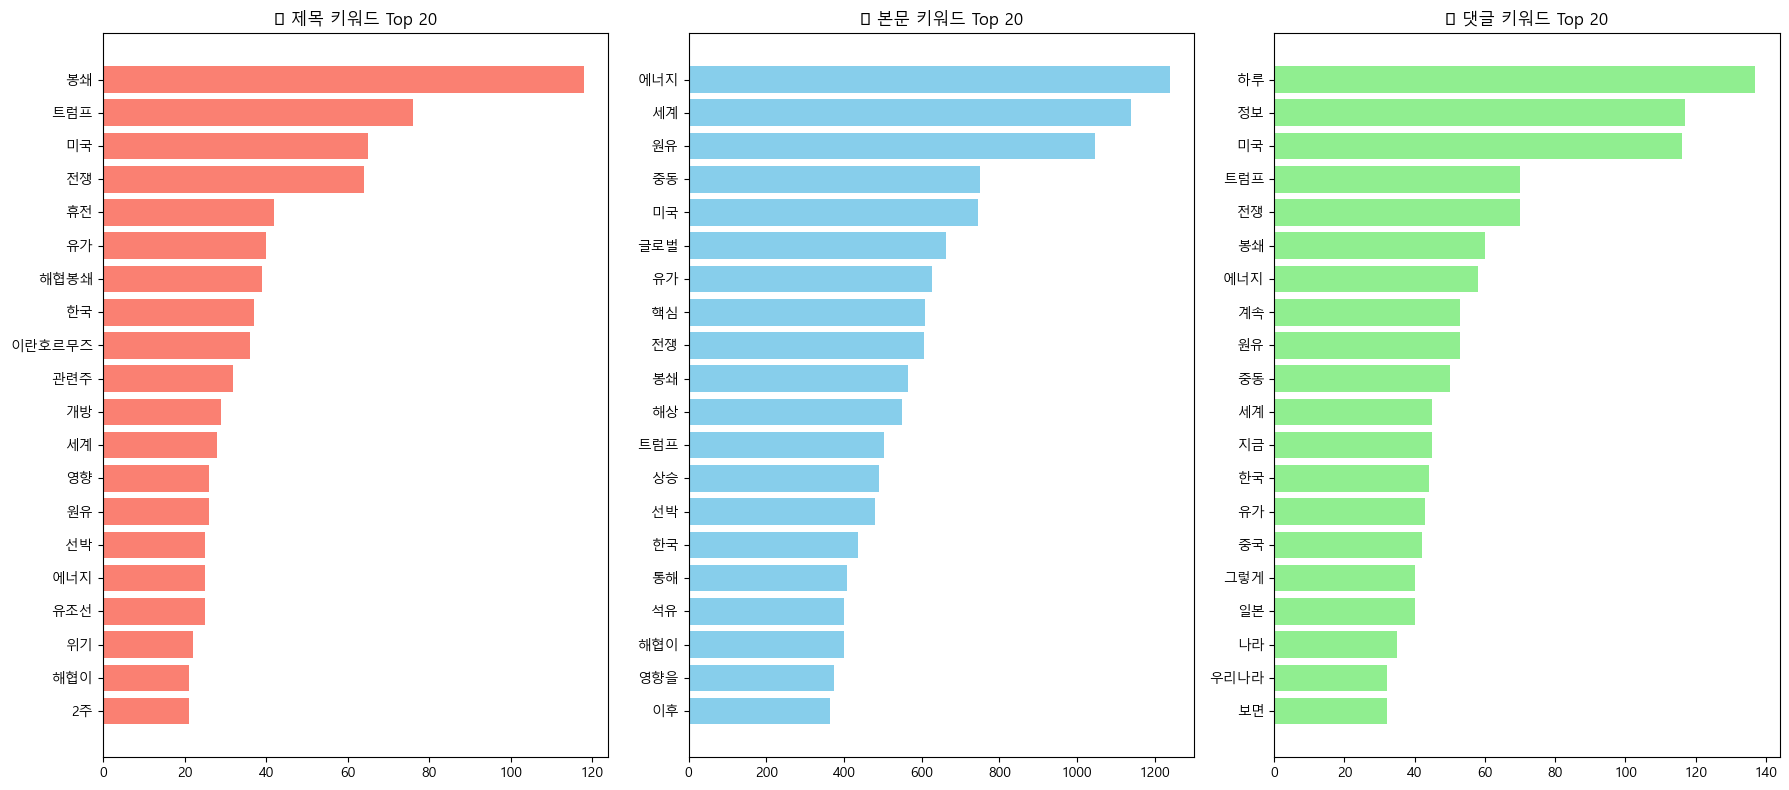

In [64]:
# 1. 각각의 컬럼에서 단어 리스트 생성
def get_top_n_words(column, n=20):
    all_words = []
    for text in df_total[column]:
        all_words.extend(text.split())
    return Counter(all_words).most_common(n)

# 2. 데이터 추출
top_title = get_top_n_words('title_final')
top_doc = get_top_n_words('doc_final')
top_comment = get_top_n_words('comment_final')

# 3. 시각화 (3개 서브플롯 생성)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# 제목 그래프
axes[0].barh([w[0] for w in top_title][::-1], [w[1] for w in top_title][::-1], color='salmon')
axes[0].set_title('📢 제목 키워드 Top 20')

# 본문 그래프
axes[1].barh([w[0] for w in top_doc][::-1], [w[1] for w in top_doc][::-1], color='skyblue')
axes[1].set_title('📝 본문 키워드 Top 20')

# 댓글 그래프
axes[2].barh([w[0] for w in top_comment][::-1], [w[1] for w in top_comment][::-1], color='lightgreen')
axes[2].set_title('💬 댓글 키워드 Top 20')

plt.tight_layout()
plt.show()

#### 워드 클라우드

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_756\305867633.py:36: UserWarning: Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_756\305867633.py:36: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_756\305867633.py:36: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) Malgun Gothic.
  plt.tight_layout()


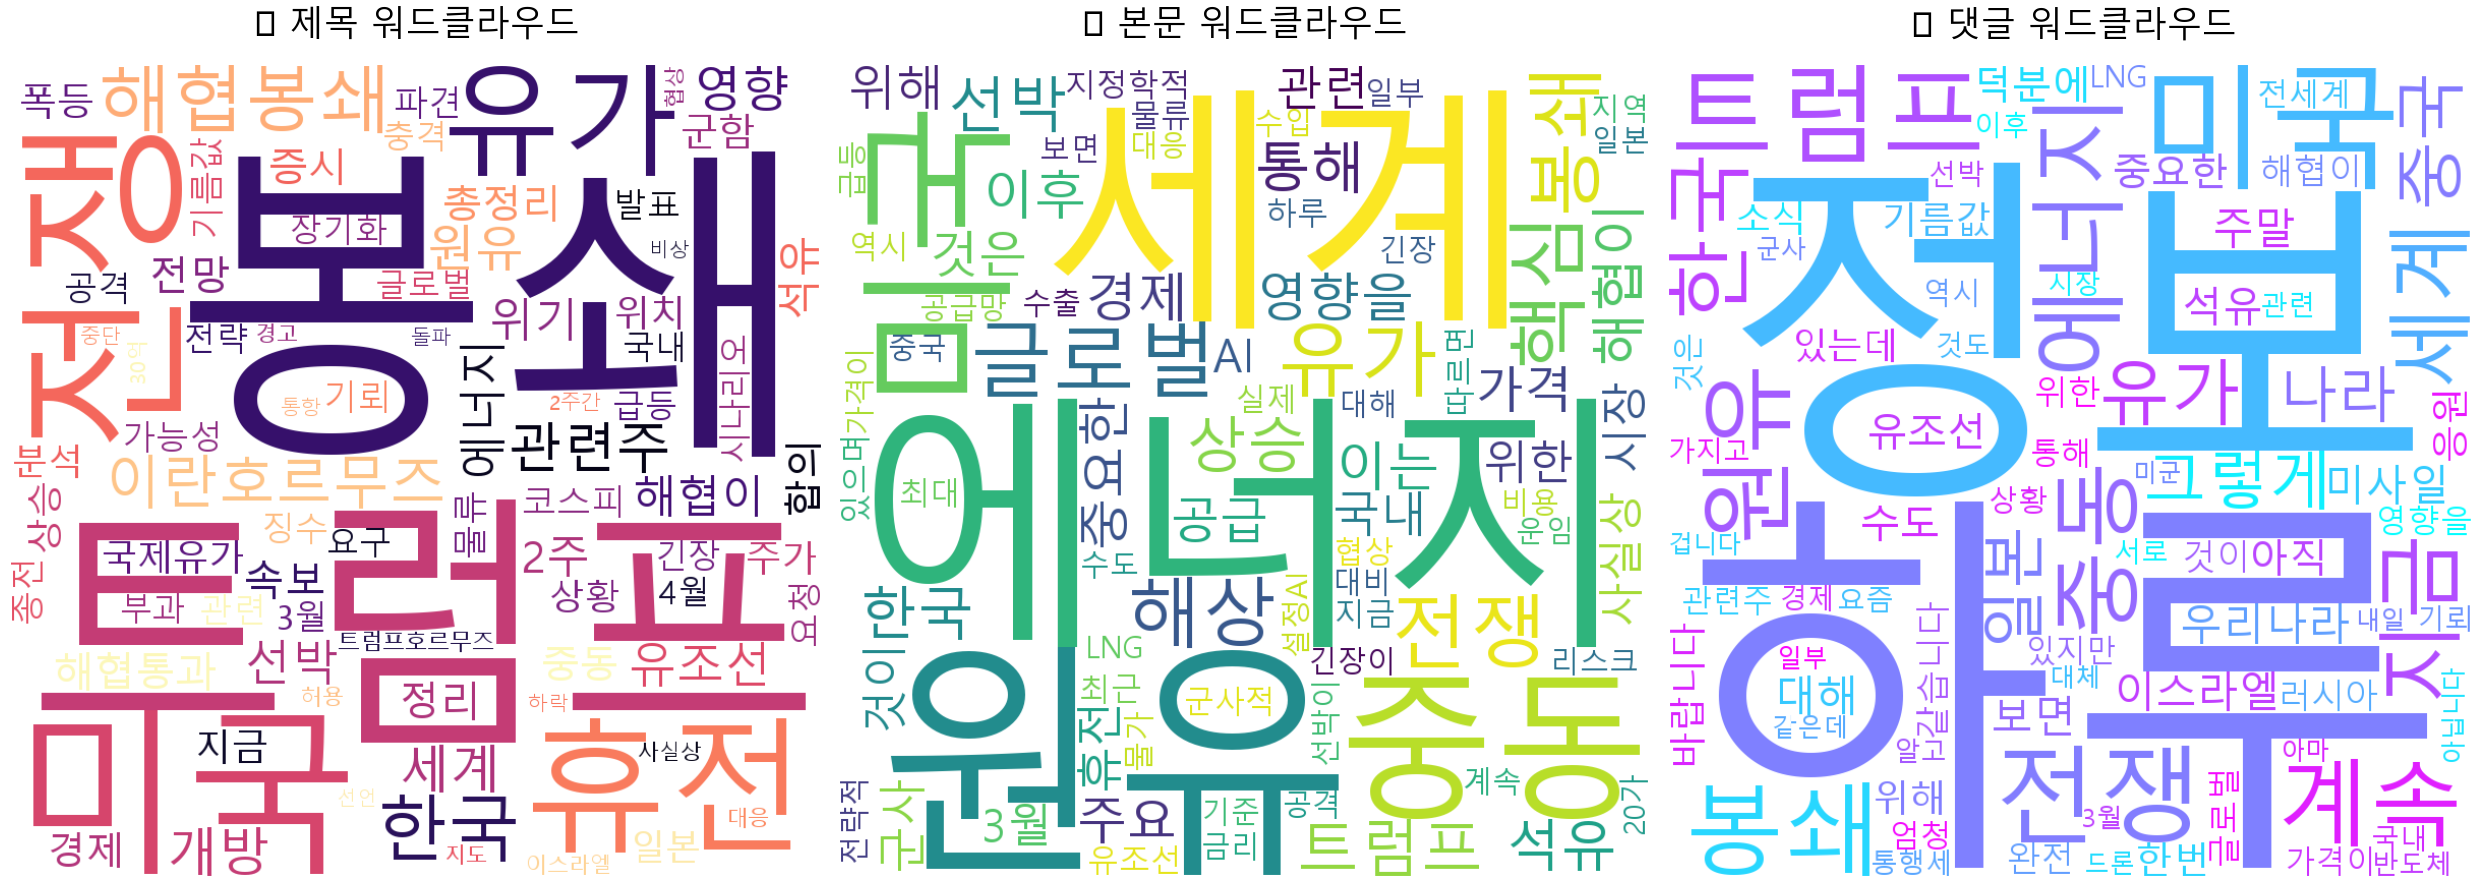

In [65]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. 워드클라우드 생성을 위한 함수 정의
def create_wc(word_counts, title, colormap, ax):
    wc = WordCloud(
        font_path=font_path,
        background_color='white',
        width=800,
        height=800,
        max_words=80,
        colormap=colormap
    )
    cloud = wc.generate_from_frequencies(word_counts)
    ax.imshow(cloud, interpolation='bilinear')
    ax.set_title(title, fontsize=25, pad=20)
    ax.axis('off')

# 2. 각 영역별 빈도 계산 (Counter 객체 활용)
title_counts = Counter(' '.join(df_total['title_final']).split())
doc_counts = Counter(' '.join(df_total['doc_final']).split())
comment_counts = Counter(' '.join(df_total['comment_final']).split())

# 3. 시각화 시작
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

# (A) 제목 - 강렬한 느낌 (magma)
create_wc(title_counts, "📢 제목 워드클라우드", "magma", axes[0])

# (B) 본문 - 차분하고 정보 위주 (viridis)
create_wc(doc_counts, "📝 본문 워드클라우드", "viridis", axes[1])

# (C) 댓글 - 감정적이고 다양한 반응 (cool)
create_wc(comment_counts, "💬 댓글 워드클라우드", "cool", axes[2])

plt.tight_layout()
plt.show()

#### TF-IDF 분석 시행 (본문)

C:\Users\황태하\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


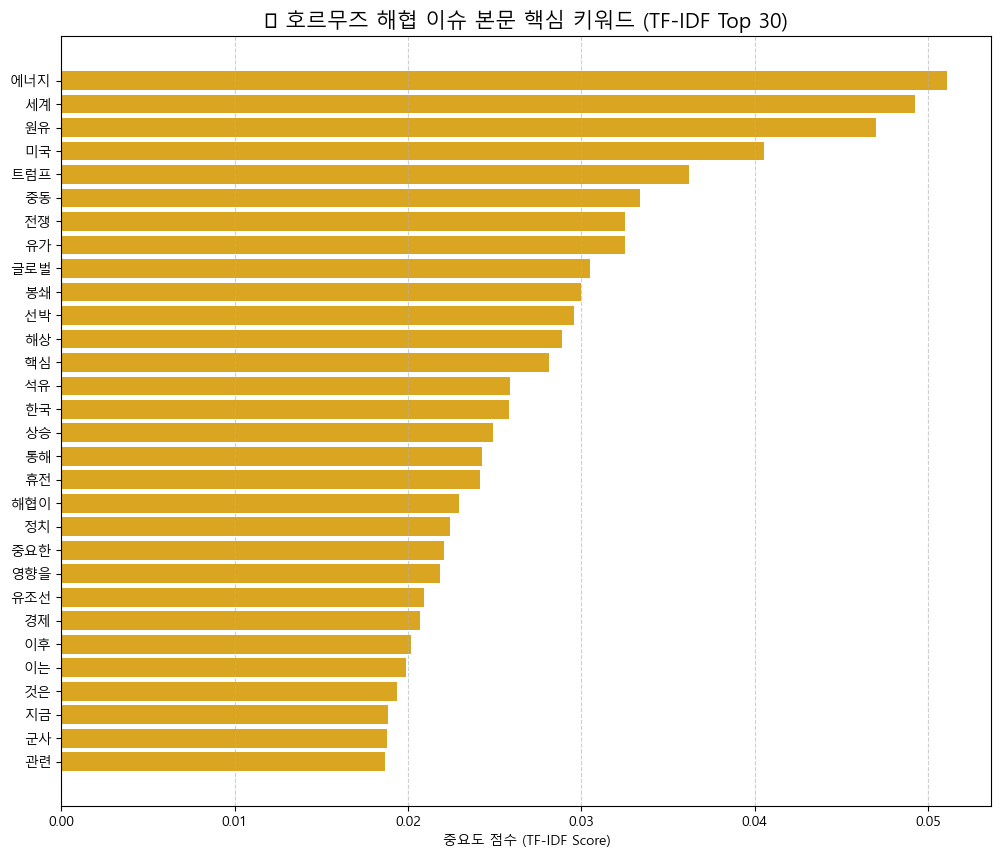

✅ 분석 완료! 상위 10개 단어:
  Word     Score
0  에너지  0.051090
1   세계  0.049229
2   원유  0.047005
3   미국  0.040518
4  트럼프  0.036198
5   중동  0.033377
6   전쟁  0.032519
7   유가  0.032488
8  글로벌  0.030504
9   봉쇄  0.029965


In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# 1. TF-IDF 벡터라이저 설정
# 본문의 핵심 단어를 잘 포착하기 위해 상위 1,000개 단어를 추출합니다.
tfidf_vec = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vec.fit_transform(df_total['doc_final'].fillna(""))

# 2. 단어별 평균 TF-IDF 점수 추출
words = tfidf_vec.get_feature_names_out()
scores = tfidf_matrix.mean(axis=0).tolist()[0]

# 3. 데이터프레임 생성 및 정렬
df_tfidf_res = pd.DataFrame(list(zip(words, scores)), columns=['Word', 'Score'])
df_tfidf_res = df_tfidf_res.sort_values(by='Score', ascending=False).reset_index(drop=True)

# 4. 시각화 (상위 30개)
plt.figure(figsize=(12, 10))
plt.barh(df_tfidf_res['Word'][:30][::-1], df_tfidf_res['Score'][:30][::-1], color='goldenrod')
plt.title('🌟 호르무즈 해협 이슈 본문 핵심 키워드 (TF-IDF Top 30)', fontsize=15)
plt.xlabel('중요도 점수 (TF-IDF Score)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print("✅ 분석 완료! 상위 10개 단어:")
print(df_tfidf_res.head(10))

#### K-Means 분석

In [67]:
from sklearn.cluster import KMeans

# 1. K-Means 모델 생성 (4개 그룹으로 설정)
# random_state는 결과를 일정하게 유지하기 위해 설정합니다.
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# 2. TF-IDF 행렬을 이용해 군집화 수행
kmeans.fit(tfidf_matrix)

# 3. 분석 결과(군집 번호)를 원본 데이터프레임에 추가
df_total['cluster'] = kmeans.labels_

print(f"✅ 1,021개의 글이 {num_clusters}개의 그룹으로 분류되었습니다.")
print(df_total['cluster'].value_counts().sort_index())

✅ 1,021개의 글이 4개의 그룹으로 분류되었습니다.
cluster
0     23
1    177
2    356
3    465
Name: count, dtype: int64


In [68]:
# 각 군집별로 핵심 단어 10개씩 추출하여 정체성 파악
print("🧐 각 그룹별 핵심 키워드를 통해 주제를 유추해봅시다:\n")

# 1. 군집별 중심점(Centroids) 가져오기
ordered_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

# 2. 이전에 사용했던 tfidf_vec 변수에서 단어 사전 가져오기
terms = tfidf_vec.get_feature_names_out()

# 3. 각 그룹(Cluster)을 대표하는 상위 10개 단어 출력
for i in range(num_clusters):
    print(f"📂 [Group {i}] 정체성 키워드:")
    top_10_indices = ordered_centroids[i, :10]
    
    # 가독성을 위해 해시태그 형태로 출력
    topic_keywords = [terms[ind] for ind in top_10_indices]
    print(f"   => {'  '.join(['#' + k for k in topic_keywords])}")
    print("-" * 80)

🧐 각 그룹별 핵심 키워드를 통해 주제를 유추해봅시다:

📂 [Group 0] 정체성 키워드:
   => #정치  #아직  #이스라엘  #선박  #연합뉴스  #지상군  #30억  #개방  #완화  #통해서
--------------------------------------------------------------------------------
📂 [Group 1] 정체성 키워드:
   => #트럼프  #휴전  #미국  #협상  #개방  #전쟁  #ai  #2주  #유가  #4월
--------------------------------------------------------------------------------
📂 [Group 2] 정체성 키워드:
   => #에너지  #세계  #원유  #해상  #글로벌  #유가  #봉쇄  #중동  #핵심  #상승
--------------------------------------------------------------------------------
📂 [Group 3] 정체성 키워드:
   => #미국  #선박  #한국  #일본  #전쟁  #트럼프  #원유  #유조선  #수도  #선박이
--------------------------------------------------------------------------------


#### 각 군집별 정체성 키워드 분석 후 군집번호와 주제 이름 매핑 작업 실시

In [70]:
# 1. 군집 번호와 주제 이름을 매핑하는 딕셔너리 생성
cluster_names = {
    0: '중동 정세 & 안보',
    1: '외교 및 정치적 변수',
    2: '실물 경제 & 에너지',
    3: '국제 관계 & 물류'
}

# 2. 'cluster_name'이라는 새로운 컬럼 생성
df_total['cluster_name'] = df_total['cluster'].map(cluster_names)

# 결과 확인
print("✅ 군집 레이블링 완료!")
display(df_total[['cluster', 'cluster_name', 'title']].head())

✅ 군집 레이블링 완료!


,cluster,cluster_name,title
0,1,외교 및 정치적 변수,미국 이란 전쟁 30일 경과 호르무즈 해협 지도로 본 현 상황
1,2,실물 경제 & 에너지,호르무즈 해협 통행료가 얼마길래 미국 이란 공동 징수 추진
2,1,외교 및 정치적 변수,뉴욕 증시 트럼프 발언 속 혼조세 호르무즈 해협 통행료 이슈
3,2,실물 경제 & 에너지,트럼프 호르무즈 해협 이름 바꾼다 이거 진짜 가능한가
4,2,실물 경제 & 에너지,호르무즈 해협 봉쇄 이유와 영향 유가 상승증시 전망


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_756\633432707.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_total, y='cluster_name',


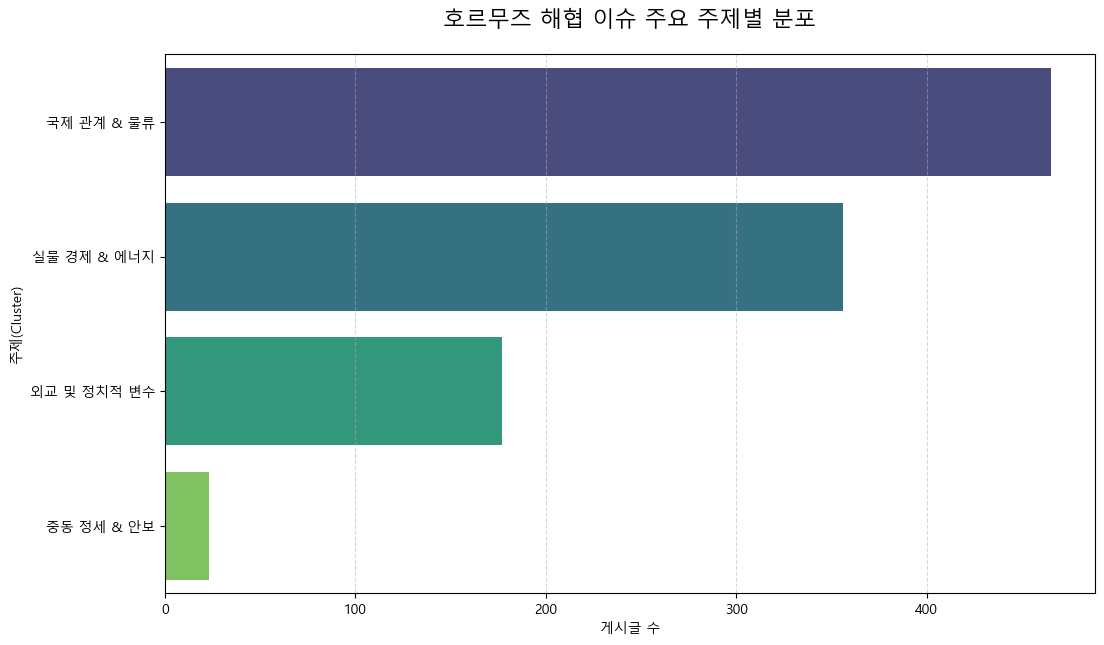

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정이 되어있어야 합니다.
plt.figure(figsize=(12, 7))

# 주제별 게시글 수 집계
sns.countplot(data=df_total, y='cluster_name', 
              order=df_total['cluster_name'].value_counts().index,
              palette='viridis')

plt.title('호르무즈 해협 이슈 주요 주제별 분포', fontsize=16, pad=20)
plt.xlabel('게시글 수')
plt.ylabel('주제(Cluster)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

### (~기간2) '호르무즈 해협' 네이버 블로그 크롤링

### (~기간2) '호르무즈 해협' 네이버 카페 크롤링

### (~기간2) '호르무즈 해협' 데이터 통합 & 전처리